# `pyfbs.nonlinearFBS` — nonlinear FBS: options & usage

Couples substructures that are described **only by their FRFs / admittances** $\mathbf{Y}(\omega)$
through a (generally nonlinear) interface force and traces the **periodic steady-state
response** of the assembly over excitation frequency — the *nonlinear forced-response
curve* (NFRC).

Method: **multi-harmonic balance (HBM)** with an AFT or DLFT treatment of the nonlinearity,
wrapped in **pseudo-arclength continuation** so the branch can be followed through the
turning points of bent (hardening / contact) resonances. Ported into pyFBS from
[pyhbm](https://github.com/tiagomrns/pyhbm) (branch `vandcard_DLFT`, commit `462a081`)
and rebuilt around pyFBS's FRF / VPT infrastructure.

This notebook is the short guide: **which options exist, when to pick which, and what
parameters they have.** Implementation details are condensed in the appendix at the end.

## 1 · A solve is three plug-ins + a driver

| Slot | Base class | Available options |
|---|---|---|
| **System** — coupling topology + force law | `FBS_System` | your subclass (§2) |
| **FRF source** — where $\mathbf{Y}(\omega)$ comes from | `FRFProvider` | `NumericalFRF` · `ModalVPFRF` · `ExperimentalFRF` (§3) |
| **Nonlinearity treatment** | `NonlinearMethod` | `AFT` · `DLFTContact` · `DLFTFriction` (§4) |

```text
 HarmonicBalanceMethod   —   predictor → Newton corrector → step adaptation   (§5)
           │  calls R, J, dR/dω on
           ▼
       FBSProblem        R = Q_rel + Y_r·F_nl − F_adm
      ┌────┼───────────┐
      ▼    ▼           ▼
 FBS_System  NonlinearMethod  FRFProvider
 (B, f_nl)   (AFT / DLFT…)    (Numerical / ModalVP / Experimental)
```

Everything is re-exported from `pyfbs.nonlinearFBS`, so a full solve is:

```python
from pyfbs.nonlinearFBS import FBSProblem, HarmonicBalanceMethod, ExperimentalFRF, AFT

HarmonicBalanceMethod.update_dependencies(harmonics, system.sample_number)  # BEFORE FBSProblem (§5)
problem = FBSProblem(system, provider, method)     # system + FRF + nonlinearity
solver  = HarmonicBalanceMethod(harmonics=harmonics, freq_domain_ode=problem, ...)
ss      = solver.solve_and_continue(...)           # SolutionSet: (fourier, omega, …) along the branch
```

Each slot is swappable independently: the same system runs on measured (`ExperimentalFRF`)
or synthesized (`NumericalFRF` / `ModalVPFRF`) admittances; the same FRF carries a smooth
spring (`AFT`) or contact (`DLFTContact` / `DLFTFriction`).

## 2 · Slot 1 — your system: subclass `FBS_System`

Declares *what is coupled* and *through which force law*. Set three attributes:

| Attribute | Shape / type | Meaning |
|---|---|---|
| `B_coupling` | `(n_int, d_total)` | signed-Boolean coupling: each row picks one interface DoF pair (+1 / −1); columns index the FRF provider's DoFs |
| `sample_number` | `int` | AFT time samples per period (must resolve the highest harmonic) |
| `omega_ref` | `float`, default `1.0` | characteristic frequency [rad/s] scaling the continuation metric — set it ≈ the resonance you sweep |

and implement four methods (all vectorized over the `Nt` time samples; `u_rel = B u` is the
relative interface gap, `u_rel_dot` the physical relative velocity):

```python
def external_term(self, tau)                       # -> (Nt, d_total, 1)    F_ext(τ), τ = ω t
def interface_force(self, u_rel, u_rel_dot, tau)   # -> (Nt, n_int, 1)      f_nl on the gap
def jacobian_interface_force(self, ...)            # -> (Nt, n_int, n_int)  ∂f_nl/∂u_rel
def jacobian_interface_force_qdot(self, ...)       # -> (Nt, n_int, n_int)  ∂f_nl/∂u̇_rel
```

Minimal example — cubic (Duffing) bushing on the 6-DoF virtual-point gap, straight from
`examples/testbench_cubicSpring`:

```python
class TestbenchCubicSpring(FBS_System):
    def interface_force(self, u_rel, udot_rel, tau):           # f = k·x + α·x³
        k, a = self.k_diag[None, :, None], self.alpha_diag[None, :, None]
        return k * u_rel + a * u_rel**3                        # (Nt, 6, 1)

    def jacobian_interface_force(self, u_rel, udot_rel, tau):  # ∂f/∂x = k + 3α·x², diagonal
        ...

    def jacobian_interface_force_qdot(self, u_rel, udot_rel, tau):
        return np.zeros((len(tau), 6, 6))                      # no velocity dependence
```

Notes:

- The Jacobians only steer Newton's convergence speed — the converged branch is set by
  `interface_force` alone.
- With the **DLFT methods** the force law lives in the method itself (§4): the system then
  only needs `B_coupling`, `sample_number` and `external_term`; the `interface_force`
  methods are never called.

## 3 · Slot 2 — FRF providers: where $\mathbf{Y}(\omega)$ comes from

A provider answers one question: *given $\omega$, return the admittance blocks
$\mathbf{Y}_n = \mathbf{Y}(n\omega)$ for the requested harmonics, restricted to the requested
DoFs.* Its `n_dofs` must equal the column count of `B_coupling`. Inside the Newton loop only
the interface ∪ excitation DoFs are synthesized (DOF reduction — cost flat in mesh size).

> `FBSProblem` needs displacement FRFs: providers with `frf_type != "receptance"` are
> rejected at construction (mobility / accelerance are for standalone FRF evaluation only).

| You have … | Pick |
|---|---|
| an FE / modal model (e.g. ANSYS); interface DoFs are model DoFs | `NumericalFRF` |
| FE models + a channel/impact layout around a **virtual point** | `ModalVPFRF` |
| only measured FRFs on a frequency grid | `ExperimentalFRF` |

### 3.1 `NumericalFRF` — modal synthesis from a real modal basis

```python
provider = NumericalFRF.from_modal(angular_eig_freq, eig_vec, modal_damping)  # Ω (n_modes,), Φ (d, n_modes)
provider = NumericalFRF.from_ansys_model(model, modal_damping)                # pyFBS Model.from_ansys(…)
```

| Option | Default | Meaning |
|---|---|---|
| `modal_damping` | required | modal damping **ratio**, scalar or per-mode array |
| `limit_modes` | `None` (= all) | mode truncation for the synthesis |
| `frf_type` | `"receptance"` | `receptance` / `mobility` / `accelerance` — the solver needs the default |

Never eigensolves and never assembles $M, C, K$: it evaluates the modal-sum receptance
(pyFBS `Model.custom_frf_synth`) at the **exact** $n\omega$ of every residual evaluation,
with the analytic $d\mathbf{Y}/d\omega$. Proportional (real-mode) damping only —
`from_ansys_model` raises on complex/damped eigensolutions.

### 3.2 `ModalVPFRF` — virtual-point admittance, VPT folded into the modes

```python
provider = ModalVPFRF.from_substructures(
    [(model_A, vpt_A, df_chn_A, df_imp_A),      # one tuple per substructure
     (model_B, vpt_B, df_chn_B, df_imp_B)],
    modal_damping=0.003)
```

| Option | Default | Meaning |
|---|---|---|
| `modal_damping` | required | modal damping ratio (scalar or per-mode) |
| `limit_modes` | `None` | modes kept **per substructure** (truncated before stacking) |
| `frf_type` | `"receptance"` | as above |

The VPT is a constant spatial projection, so it commutes through the modal sum: only the
VP-projected participation matrices $\Psi_c = \mathbf{T}_u\Phi_c$, $\Psi_i = \mathbf{T}_f^T\Phi_i$
are stored and the synthesis runs **directly in virtual-point space** — the physical
admittance is never assembled (cost $O(n_{modes} N_{vp}^2)$, flat in mesh size).
`n_dofs == N_{vp}`, so the `B_coupling` columns count virtual-point DoFs. Substructures are
stacked block-diagonally (uncoupled until the interface force couples them).

### 3.3 `ExperimentalFRF` — measured admittance grid

```python
provider = ExperimentalFRF(omega_frf, Y)     # omega_frf (N_freq,) [rad/s], Y (N_freq, d, d) complex
```

| Option | Default | Meaning |
|---|---|---|
| `fd_step` | `1e-6` | central-difference step [rad/s] for $d\mathbf{Y}/d\omega$ |

Cubic-spline interpolation of only the requested channels (cached per DoF set). Conjugate
symmetry $\mathbf{Y}(-\omega) = \overline{\mathbf{Y}(\omega)}$ is applied automatically.
**The measured grid must cover $n_{max}\,\omega_{max}$** — outside the grid it warns and
extrapolates.

## 4 · Slot 3 — nonlinear methods: how the interface force is treated

| Method | Physics | Parameters | Force law lives in |
|---|---|---|---|
| `AFT()` | any **smooth** force $f(u_{rel}, \dot u_{rel})$ | — | your `FBS_System.interface_force` |
| `DLFTContact(…)` | unilateral (one-sided) normal contact | `epsilon`, `g_zero` | the method |
| `DLFTFriction(…)` | unilateral contact **+ Coulomb friction** | `epsilon_N`, `epsilon_T`, `mu`, `g_zero`, `n_tangential` | the method |

### 4.1 `AFT` — Alternating Frequency–Time

```python
method = AFT()      # no parameters
```

Each evaluation: inverse FFT $\mathbf{Q}_{rel} \to u_{rel}(\tau)$, evaluate the system's
`interface_force` in time, FFT back. Use it for smooth nonlinearities — cubic/Duffing
springs, nonlinear damping, or *regularized* (e.g. tanh-smoothed penalty) contact. The
Jacobians come from your system's `jacobian_interface_force` / `…_qdot`.

### 4.2 `DLFTContact` — Dynamic Lagrangian normal contact

```python
method = DLFTContact(epsilon=0.5 * k_rod, g_zero=0.2e-3)
```

| Parameter | Default | Meaning |
|---|---|---|
| `epsilon` | `1.0` | penalty / Lagrangian factor [stiffness units] — scale it against the interface stiffness (the two-rod example uses `0.5 · k_rod`) |
| `g_zero` | `0.0` | initial gap $g_0$: contact when $u_{rel} > g_0$ |

Rigid unilateral contact without an LCP solve: at every residual evaluation the contact
force is *slaved* to $\mathbf{Q}_{rel}$ by the prediction
$\lambda_p = \mathrm{IDFT}\!\big[\mathbf{Z}_r(\mathbf{F}_{adm}-x_r)\big] + \varepsilon(x_r - g_0)$
and the correction $\lambda = \max(0, \lambda_p)$. **The converged branch is
ε-independent** — ε only conditions the iteration.

### 4.3 `DLFTFriction` — contact + Coulomb friction (Nacivet et al., JSV 265(1), 2003)

```python
method = DLFTFriction(epsilon_N=1e2 * k_c, epsilon_T=1e2 * k_c, mu=0.3, n_tangential=2)
```

| Parameter | Default | Meaning |
|---|---|---|
| `epsilon_N` | `1.0` | normal penalty factor (large vs. the interface dynamic stiffness, e.g. ~`1e2 · k_contact`) |
| `epsilon_T` | `1.0` | tangential penalty factor |
| `mu` | `0.0` | Coulomb friction coefficient |
| `g_zero` | `0.0` | normal gap offset |
| `n_tangential` | `1` | tangential components per contact node: 1 = line contact, 2 = friction disc |

Same DLFT skeleton, but the correction is a **sequential stick / slip / separation sweep**
over the time samples. The interface DoFs must be grouped in per-node `[N, T…]` blocks:
`n_int` divisible by `1 + n_tangential`, normal slot first. Caveat: in 1-D gross slip the
analytic tangent's T→T block vanishes and Newton contracts poorly — heavy-slip cases favor
a Powell-type solver.

## 5 · The driver: `HarmonicBalanceMethod` + continuation options

```python
solver = HarmonicBalanceMethod(
    harmonics       = [1, 3, 5],                 # harmonic set to balance (0 = DC is allowed)
    freq_domain_ode = problem,                   # the FBSProblem
    corrector_solver           = NewtonRaphson,               # default
    corrector_parameterization = OrthogonalParameterization,  # default | ArcLengthParameterization
    predictor                  = TangentPredictorOne,         # default | TangentPredictorBordered | …
    step_length_adaptation     = ExponentialAdaptation,       # default | BiExponentialAdaptation
)
```

> **Order matters:** `FBSProblem` reads the harmonic set from the `Fourier` class variables
> at construction, so call `HarmonicBalanceMethod.update_dependencies(harmonics,
> system.sample_number)` **before** building the `FBSProblem`. (The `HarmonicBalanceMethod`
> constructor calls it again — the repeat is harmless.)

**Corrector parameterization** — the scalar equation pinning Newton to the curve:

| Class | Constraint | When |
|---|---|---|
| `OrthogonalParameterization` (default) | correction ⟂ tangent through the predicted point (linear) | fast Newton, robust through turning points |
| `ArcLengthParameterization` | Keller sphere of radius `step` around the last solution (quadratic) | classic pseudo-arclength; used by the shipped examples |

**Predictor** — the tangent direction:

| Class | Kernel assumption | When |
|---|---|---|
| `TangentPredictorOne` (default) | dim 1 (null space) | cheap; fine away from limit points |
| `TangentPredictorBordered` | none — Keller bordered system | stays stable when the Jacobian goes rank-deficient at limit points → **recommended for bent NFRCs** (the examples use it) |
| `TangentPredictorTwo` / `TangentPredictorRobust` | dim 2 / verified | autonomous systems (phase-shift direction removed) |

**Step-length adaptation:** `ExponentialAdaptation(base, maximum_step_length,
minimum_step_length, goal_number_of_iterations, initial_step_length=None)` multiplies the
step by `base^(goal − iterations)` after every solve; `BiExponentialAdaptation` adds a
separate `base_decrease` for shrinking.

**`solve_and_continue(...)` arguments:**

| Argument | Default | Meaning |
|---|---|---|
| `maximum_number_of_solutions` | — | hard cap on branch points |
| `angular_frequency_range` | — | `[ω_a, ω_b]` in rad/s (sorted internally); termination window |
| `solver_kwargs` | — | Newton settings: `maximum_iterations`, `absolute_tolerance` (internally rescaled by √2/Nₜ), optional `relative_tolerance`, `stagnation_tolerance` |
| `step_length_adaptation_kwargs` | — | see above |
| `predictor_kwargs` | `{}` | e.g. `rcond` for the null-space predictors |
| `initial_guess` | `None` | `FourierOmegaPoint`; `None` → zero amplitude at `ω_a` |
| `initial_reference_direction` | `None` | orients the first tangent — e.g. `omega=-1.0` to sweep downward |
| `jacobian_update_frequency` | `3` | Newton reuses the Jacobian up to this many iterations |
| `jacobian_reuse_delta_threshold` | `1e-3` | ‖Δx‖/‖x‖ above which the Jacobian is refreshed anyway |
| `maximum_predictor_corrector_loops_per_solution` | `10` | retries with adapted step length before terminating |
| `verbose` | `True` | one progress line per solution (set `False` in notebooks) |

**Seeding and post-processing:**

```python
ig = FourierOmegaPoint.zero_amplitude(dimension=n_int, omega=w_start)             # cold start
ig = FourierOmegaPoint.new_from_first_harmonic(Q1, omega=w_start)                 # warm start (e.g. linear response)
rd = FourierOmegaPoint.new_from_first_harmonic(np.zeros((n_int, 1), complex), omega=-1.0)  # sweep downward

ss = solver.solve_and_continue(initial_guess=ig, initial_reference_direction=rd, ...)

for four, w in zip(ss.fourier, ss.omega):            # SolutionSet: one entry per converged point
    full = problem.compute_full_response(four, w)    # back to ALL physical DoFs (one extra FRF call)
    Fourier_Real.compute_time_series(full)           # → full.time_series (Nt, d_total, 1)
```

## 6 · End-to-end example: cubic-spring testbench (AFT + ExperimentalFRF)

The pyFBS lab testbench (substructures A + B, ANSYS FE models) coupled by a **cubic
hardening bushing** $f = k\,x_r + \alpha\,x_r^3$ on the six virtual-point interface DoFs.
The admittance grid is built once (ANSYS modes → VPT → block-diagonal
$Y = \mathrm{diag}(Y_A, Y_B)$) and handed to `ExperimentalFRF`; `AFT` + arc-length
continuation trace **two branches** (the strongly bent first resonance is multivalued, so
the sweep direction — set via `initial_reference_direction` — decides which part you land
on): sweeping **down from 1000 Hz** yields the broadband low-amplitude branch, sweeping
**up from 20 Hz** climbs the resonant flank through the bend to its nose (~140 Hz) and
folds back. The linear (α = 0) LM-FBS receptance is drawn as backbone, and an independent
RBE2 + Craig-Bampton + pyhbm reference overlays the bend.

(Condensed from `examples/testbench_cubicSpring/main.py`; needs the local ANSYS
lab-testbench data.)

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

import pyfbs
from pyfbs.nonlinearFBS import (
    Fourier_Real, FourierOmegaPoint, FBSProblem, ExperimentalFRF, AFT,
    HarmonicBalanceMethod, ArcLengthParameterization, TangentPredictorBordered,
)

# example folder: system definition + ./lab_testbench data
if not os.getcwd().endswith("testbench_cubicSpring"):
    os.chdir("examples/testbench_cubicSpring")
sys.path.insert(0, os.getcwd())
from dynamical_system import build_testbench_data, TestbenchCubicSpring, N_IF

# cubic bushing  f = k·x + α·x³  per interface DoF, driven at F0
k, alpha, F0 = 1.0e3, 1.0e6, 50.0
HARMONICS    = [1, 3, 5, 7]          # cubic forcing generates odd harmonics

data   = build_testbench_data(k, k, alpha, alpha, 0.0, 0.0, f_resolution=0.1)
system = TestbenchCubicSpring(data, F0=F0)
HarmonicBalanceMethod.update_dependencies(HARMONICS, system.sample_number)   # before FBSProblem

100%|██████████| 10/10 [00:00<00:00, 17133.59it/s]


100%|██████████| 3/3 [00:00<00:00, 6377.55it/s]


100%|██████████| 10/10 [00:00<00:00, 19427.07it/s]


12 18


In [2]:
problem = FBSProblem(system, ExperimentalFRF(data["omega"], data["Y"]), AFT())
solver  = HarmonicBalanceMethod(
    harmonics=HARMONICS, freq_domain_ode=problem,
    corrector_parameterization=ArcLengthParameterization,
    predictor=TangentPredictorBordered)

f_lo, f_hi = 20.0, 1000.0
w_lo, w_hi = 2 * np.pi * f_lo, 2 * np.pi * f_hi

kwargs = dict(
    maximum_number_of_solutions   = 10000,
    angular_frequency_range       = [w_lo, w_hi],
    solver_kwargs                 = {"maximum_iterations": 300, "absolute_tolerance": 1e-6},
    step_length_adaptation_kwargs = {"base": 4.0,
                                     "initial_step_length": 0.1 * 2 * np.pi,
                                     "maximum_step_length": 5 * 2 * np.pi,
                                     "minimum_step_length": 1e-7,
                                     "goal_number_of_iterations": 3},
    jacobian_update_frequency     = 1,
    verbose                       = False)

def sweep(w_start, direction):
    # cold zero start at w_start; direction = +1.0 / -1.0 orients the first tangent
    ig = FourierOmegaPoint.zero_amplitude(dimension=N_IF, omega=w_start)
    rd = FourierOmegaPoint.new_from_first_harmonic(np.zeros((N_IF, 1), complex), omega=direction)
    return solver.solve_and_continue(initial_guess=ig, initial_reference_direction=rd, **kwargs)

ss_dn = sweep(w_hi, -1.0)   # broadband low-amplitude branch, 1000 Hz -> 20 Hz
ss_up = sweep(w_lo, +1.0)   # resonant branch: climbs the bend to its nose, folds back
print(f"down: {len(ss_dn)} points ({min(ss_dn.omega)/2/np.pi:.1f} … {max(ss_dn.omega)/2/np.pi:.1f} Hz), "
      f"up: {len(ss_up)} points (nose at {max(ss_up.omega)/2/np.pi:.1f} Hz)")

C:\Users\yanni\Desktop\TUM\Bachelorarbeit\Fast_numerical_solution_for_nonlinear_FE_dynamics\pyFBS_clone\pyFBS\pyfbs\nonlinearFBS\frf_provider.py:266: UserWarning: omega outside FRF data range [0, 50264.8541]. Extrapolating.
  warnings.warn(
C:\Users\yanni\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\linalg\_linalg.py:2768: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


Newton-Raphson: non-finite residue at iteration 251, aborting corrector step

Terminate: outside frequency range after 224 solutions
Total solving time: 3.2831389904022217 seconds
Newton-Raphson: non-finite residue at iteration 86, aborting corrector step

Terminate: outside frequency range after 309 solutions
Total solving time: 0.7750282287597656 seconds
down: 224 points (19.1 … 1000.0 Hz), up: 309 points (nose at 141.1 Hz)


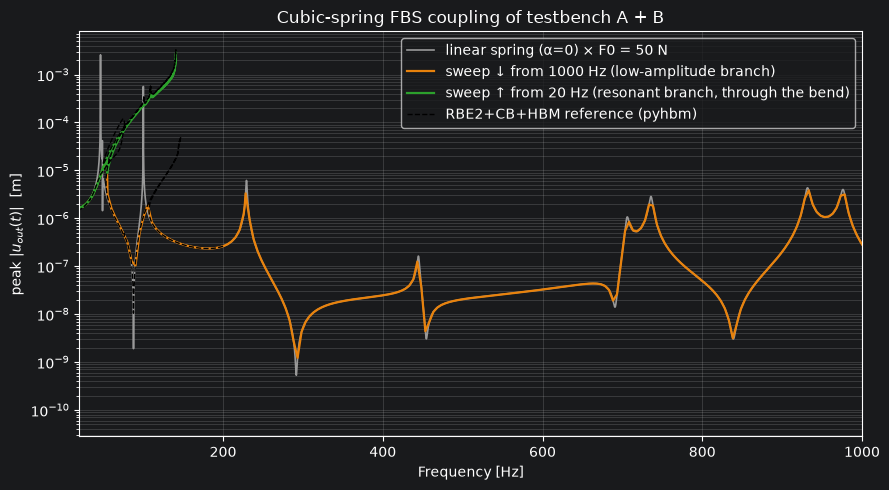

In [3]:
def branch_amplitude(ss):
    # peak |u_out(t)| over one period at every converged point of a branch
    f = np.array(ss.omega) / (2 * np.pi)
    a = np.zeros(len(f))
    for i, (four, w) in enumerate(zip(ss.fourier, ss.omega)):
        full = problem.compute_full_response(four, w)      # all physical DoFs
        Fourier_Real.compute_time_series(full)
        a[i] = np.max(np.abs(full.time_series[:, system.out_full, 0]))
    return f, a

f_dn, amp_dn = branch_amplitude(ss_dn)
f_up, amp_up = branch_amplitude(ss_up)

# linear (α = 0) LM-FBS receptance of the out/in channel as backbone
Bc = data["Bc"]
Gamma = np.zeros((len(data["freq"]), N_IF, N_IF))
Gamma[:, np.arange(N_IF), np.arange(N_IF)] = 1.0 / data["k_diag"]
YBt, BY = data["Y"] @ Bc.T, Bc @ data["Y"]
G_int   = pyfbs.tpinv(Bc @ YBt + Gamma, trunc=0)
coupling_row = YBt[:, [system.out_full], :] @ G_int @ BY[:, :, [system.inp_full]]
mag_lin = np.abs(data["Y"][:, system.out_full, system.inp_full] - coupling_row[:, 0, 0])

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(data["freq"], mag_lin * F0, '-', color="#999999", lw=1.2,
            label=f"linear spring (α=0) × F0 = {F0:g} N")
ax.semilogy(f_dn, amp_dn, '-', color="#E8820C", lw=1.6,
            label="sweep ↓ from 1000 Hz (low-amplitude branch)")
ax.semilogy(f_up, amp_up, '-', color="#2ca02c", lw=1.6,
            label="sweep ↑ from 20 Hz (resonant branch, through the bend)")
if os.path.exists("reference_rbe2_cb_hbm.csv"):     # independent RBE2 + Craig-Bampton + pyhbm run
    ref = np.loadtxt("reference_rbe2_cb_hbm.csv", delimiter=",", skiprows=1)
    ax.semilogy(ref[:, 0], ref[:, 2], '--', color="k", lw=1.0, label="RBE2+CB+HBM reference (pyhbm)")
ax.set_xlim(f_lo, f_hi)
ax.set_xlabel("Frequency [Hz]"); ax.set_ylabel("peak $|u_{out}(t)|$  [m]")
ax.set_title("Cubic-spring FBS coupling of testbench A + B")
ax.grid(True, which="both", alpha=0.3); ax.legend()
fig.tight_layout(); plt.show()

## 7 · Runnable examples (`pyfbs/nonlinearFBS/examples/`)

| Folder | System | Nonlinearity | FRF source | Shows |
|---|---|---|---|---|
| `two_rod_example` | two FE rods across a gap | vibro-impact: `DLFTContact` **or** regularized penalty via `AFT` (switch `METHOD` / `FRF_SOURCE` at the top of `main.py`) | `NumericalFRF` / `ExperimentalFRF` | contact NFRC vs. linear no-contact baseline |
| `testbench_linearSpring` | pyFBS lab testbench A + B | linear bushing | `ModalVPFRF` (default) / `ExperimentalFRF` — `FRF_SOURCE` switch | solver vs. closed-form LM-FBS receptance (pipeline verification); full-mesh response animation with excitation/output arrows |
| `testbench_cubicSpring` | pyFBS lab testbench A + B | cubic hardening bushing (+ optional cubic damping) | `ModalVPFRF` (default) / `ExperimentalFRF` — `FRF_SOURCE` switch | bent NFRC; full-mesh response animation with excitation/output arrows; RBE2/RBE3 + Craig-Bampton + pyhbm reference comparison via `plot_comparison.py`; parameter studies in `parameter_study/` |
| `bars_with_gap_ansys` | — | — | — | ANSYS `.full` / `.rst` source data only (no runnable script) |

Each case is a self-contained script: `python main.py` (the linear testbench:
`testbench_linearSpringCoupling.py`).

## Appendix — implementation notes (condensed)

**Residual** (`hbm_problems.FBSProblem`). Unknown: $\mathbf{Q}_{rel}$, the Fourier
coefficients of the relative interface displacement $u_{rel} = \mathbf{B}u$. With
$\mathbf{Y}_r = \mathbf{B}\mathbf{Y}\mathbf{B}^T$ and
$\mathbf{F}_{adm} = \mathbf{B}\mathbf{Y}\mathbf{F}^{ext}$, per harmonic:

$$\mathbf{R} = \mathbf{Q}_{rel} + \mathbf{Y}_r\,\mathbf{F}^{nl}(\mathbf{Q}_{rel}) - \mathbf{F}_{adm} = \mathbf{0},$$

$$\frac{\partial\mathbf{R}}{\partial\mathbf{Q}_{rel}} = \mathbf{I} + (\mathbf{Y}_r)_{RI}\,\mathbf{J}^{nl}_{RI},
\qquad
\frac{\partial\mathbf{R}}{\partial\omega} = \mathbf{B}\frac{d\mathbf{Y}}{d\omega}\big(\mathbf{B}^T\mathbf{F}^{nl} - \mathbf{F}^{ext}\big) + \mathbf{Y}_r\frac{\partial\mathbf{F}^{nl}}{\partial\omega}.$$

Everything is solved in real–imaginary (RI) packed form: complex
$c \to [\mathrm{Re}\,c;\ \mathrm{Im}\,c]$, complex operators →
$\begin{bmatrix}\mathrm{Re} & -\mathrm{Im}\\ \mathrm{Im} & \mathrm{Re}\end{bmatrix}$.

**File map**

| File | Role |
|---|---|
| `dynamical_system.py` | `FBS_System` — what you subclass (§2) |
| `frf_provider.py` | `FRFProvider` + the three providers (§3) |
| `nonlinear_method.py` | `NonlinearMethod` + the AFT / DLFT strategies (§4) |
| `hbm_problems.py` | `FBSProblem` — assembles $R$, $J$, $\partial R/\partial\omega$ |
| `frequency_domain.py` | Fourier ↔ time machinery, RI packing, AFT Jacobians |
| `numerical_continuation/` | `NewtonRaphson` corrector + predictors + step adaptation (§5) |
| `core.py` | `HarmonicBalanceMethod.solve_and_continue` — the driver loop |

**Key mechanics**

- *Per-point caching*: each `FourierOmegaPoint` carries $Y$, $dY/d\omega$, $BY$, $Y_r$,
  $F_{adm}$, the DLFT balancing solve and the contact mask, so residual / Jacobian /
  $\partial R/\partial\omega$ share one evaluation per Newton step.
- *DOF reduction*: inside the loop the provider only synthesizes the interface ∪ excitation
  DoFs (`in_dofs`); `compute_full_response` makes one `Y[all_dofs, in_dofs]` call per
  converged point to recover every physical DoF.
- *Physical frequencies*: the continuation runs directly in rad/s; `Dscale` (built from
  `omega_ref`) only conditions the linear algebra (scaled tangent metric ‖D⁻¹v‖, column
  scaling in Newton) — the curve itself is un-rescaled.
- *Tolerance rescaling*: `solve_and_continue` multiplies the given `absolute_tolerance` by
  √2/Nₜ so it acts as a time-domain-equivalent tolerance.
- *Newton robustness*: Armijo backtracking line search + lazy Jacobian reuse
  (`jacobian_update_frequency`, `jacobian_reuse_delta_threshold`).
- *DC-harmonic fix* (`JacobianFourier_Real`): with the rFFT convention the DC bin lacks the
  factor 2, so the Hankel-doubling $m=0$ column is halved when harmonic 0 is present (found
  by a finite-difference Jacobian check).

**Changes since the pyhbm fork** (baseline `vandcard_DLFT` @ `462a081`, imported by pyFBS
commit `b443c49`):

- Trimmed to the FBS path — the single-subsystem `FRFProblem`, the first/second-order ODE
  hierarchy and the `stability/`, `validation/`, `io/` subpackages were dropped.
- `frf_provider.py` rebuilt around pyFBS: DOF-reduced interface (`out_dofs`/`in_dofs` +
  `n_dofs`); `NumericalFRF` now takes a real modal basis (`from_modal` /
  `from_ansys_model`) instead of inverting $(M, C, K)$ per harmonic; `ModalVPFRF` is new;
  `ExperimentalFRF` splines per requested channel instead of the whole matrix.
- `FBS_System` slimmed to `B_coupling` / `sample_number` / `omega_ref` + the semantic force
  methods (the $M, C, K$ attributes are gone — the system is defined by its FRF).
- `FBSProblem`: `d_total` from `provider.n_dofs`, the `in_dofs` reduction, the
  `Dscale`/`omega_ref` metric, and `compute_full_response`.
- Continuation: scaled metric in predictors/parameterizations, `Dscale` column scaling +
  Armijo line search + lazy Jacobian reuse in `NewtonRaphson`, and the upstream
  `TangentPredictorRobust` step-length bug fixed.
- New pyFBS examples: `testbench_linearSpring`, `testbench_cubicSpring` (incl.
  `parameter_study/` and the RBE2 + Craig-Bampton reference).